# Volumetric Analysis for Particle Detection

In [23]:
from pathlib import Path
import circle_fit
import cv2
import numpy as np
import matplotlib.pyplot as plt
import skimage
import scipy

from numpy.typing import NDArray
from scipy.ndimage import gaussian_filter1d, map_coordinates

import sys

sys.path.insert(0, str(Path.cwd().parent))

from metal import estimate_metal_threshold, extract_metal_mask, estimate_grayscale_range
from polar import (
    build_polar_maps,
    build_inverse_maps,
    cartesian_to_polar,
    polar_to_cartesian,
)
from enhance import softmax_projection

from volume import load_volume, voxel_size_mm

plt.style.use("dark_background")


# Configuration & Utilities

In [4]:
data_dir = Path.cwd().parent / "Data"
vol = load_volume(data_dir / "M50L-06.raw")
z_top, z_bottom = 200, 4070
vol = vol[z_top:z_bottom]
vol_center_row = (vol.shape[1]) / 2
vol_center_col = (vol.shape[2]) / 2
pixel_size_mm = voxel_size_mm(data_dir / "M50L-06.raw")
print(f"Shape : {vol.shape}\nDtype : {vol.dtype}\nVoxel : {pixel_size_mm} mm")

Shape : (3870, 1425, 1425)
Dtype : uint8
Voxel : (0.01640435, 0.01640435, 0.01640435) mm


## Utils

In [5]:
def plot(img: np.ndarray, title: str = "", figsize: tuple = (12, 12)) -> None:
    plt.figure(figsize=figsize)
    plt.imshow(img, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()


# Identify Landmark Grayscale Values - Air, Metal and Max
Any gray level below 'air' value is considered background air
Any gray level above the 'metal' value is considered hig-z metal
Any gray level above the estimated max grayscale value is assumed saturated

In [6]:
air_grayvalue, max_grayvalue = estimate_grayscale_range(vol, slice_step=200)
min_grayvalue = air_grayvalue
metal_threshold = estimate_metal_threshold(vol, air_grayvalue, slice_step=200)
print(f"Estimated Air Gray Value: {air_grayvalue}")
print(f"Estimated Metal Threshold: {metal_threshold}")
print(f"Estimated Max Gray Value: {max_grayvalue}")

Right Peak: 128, Other Peaks: [180], Prominences: [27888.15163607]
Estimated Air Gray Value: 93
Estimated Metal Threshold: 154
Estimated Max Gray Value: 219


# Set the slab location and thickness

In [7]:
# slice range 905-914
slice_loc = 910

slab_thickness = 11
z_range = slice_loc - slab_thickness // 2, slice_loc + slab_thickness // 2 + 1
slab = vol[z_range[0] : z_range[1], :, :]

# Estimate the center axis throughout the volume

In [ ]:
cx, cy = [], []
z_samples = np.arange(slab_thickness//2, vol.shape[0] - slab_thickness//2, 200)
z_samples = list(z_samples)
if vol.shape[0] - 1 - slab_thickness//2 not in z_samples:
    z_samples.append(vol.shape[0] - 1 - slab_thickness//2)
print("Number of z samples:", len(z_samples))
for z in z_samples:
    slab = vol[z - 5 : z + 6, :, :]
    max_proj = np.max(slab, axis=0)
    metal_mask = extract_metal_mask(max_proj, metal_threshold, min_area=100)
    contours, _ = cv2.findContours(
        metal_mask.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
    )
    if not contours:
        print(f"No contours found in slice {z}")
        continue
    outer = max(contours, key=lambda x: cv2.contourArea(x))
    outer_pts = outer[:, 0, :]
    cc, rc, r, residual = circle_fit.taubinSVD(outer_pts)
    cx.append(cc)
    cy.append(rc)

Number of z samples: 21
Slice 5: Circle center: (695.80, 718.97), radius: 640.12, residual: 0.38
Slice 205: Circle center: (696.42, 718.11), radius: 640.05, residual: 0.41
Slice 405: Circle center: (697.03, 717.35), radius: 640.10, residual: 0.45
Slice 605: Circle center: (697.79, 716.62), radius: 640.20, residual: 0.54
Slice 805: Circle center: (698.65, 715.83), radius: 640.28, residual: 0.71
Slice 1005: Circle center: (699.58, 714.95), radius: 640.37, residual: 0.82
Slice 1205: Circle center: (700.47, 713.98), radius: 640.50, residual: 0.83
Slice 1405: Circle center: (701.33, 712.95), radius: 640.63, residual: 0.76
Slice 1605: Circle center: (702.09, 711.88), radius: 640.75, residual: 0.77
Slice 1805: Circle center: (702.81, 710.84), radius: 640.83, residual: 0.84
Slice 2005: Circle center: (703.44, 709.88), radius: 640.91, residual: 0.88
Slice 2205: Circle center: (704.05, 708.98), radius: 641.04, residual: 0.88
Slice 2405: Circle center: (704.70, 708.13), radius: 641.13, residual: 

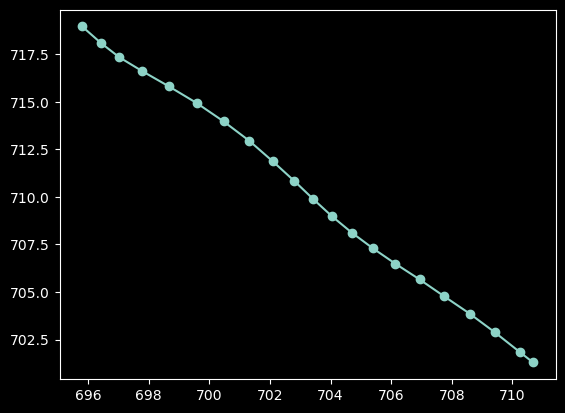

In [88]:
plt.plot(cx, cy, "o-")

# Extract the metal mask for the slab

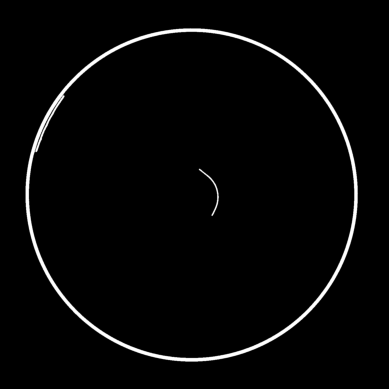

In [8]:
metal = extract_metal_mask(np.max(slab, axis=0), metal_threshold, min_area=200)
plt.imshow(metal, cmap="gray")
plt.axis("off")
plt.show()

# Circle fitting the to outer can wall

In [ ]:
contours, _ = cv2.findContours(
    metal.astype(np.uint8), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE
)
print("Number of contours:", len(contours))
outer = max(contours, key=lambda x: cv2.contourArea(x))
outer_pts = outer[:, 0, :]

cc, rc, r, residual = circle_fit.taubinSVD(outer_pts)
print(f"Circle center: ({cc:.2f}, {rc:.2f}), radius: {r:.2f}, residual: {residual:.2f}")

Number of contours: 1
Circle center: (699.14, 715.39), radius: 640.33, residual: 0.77


(1425, 1425)


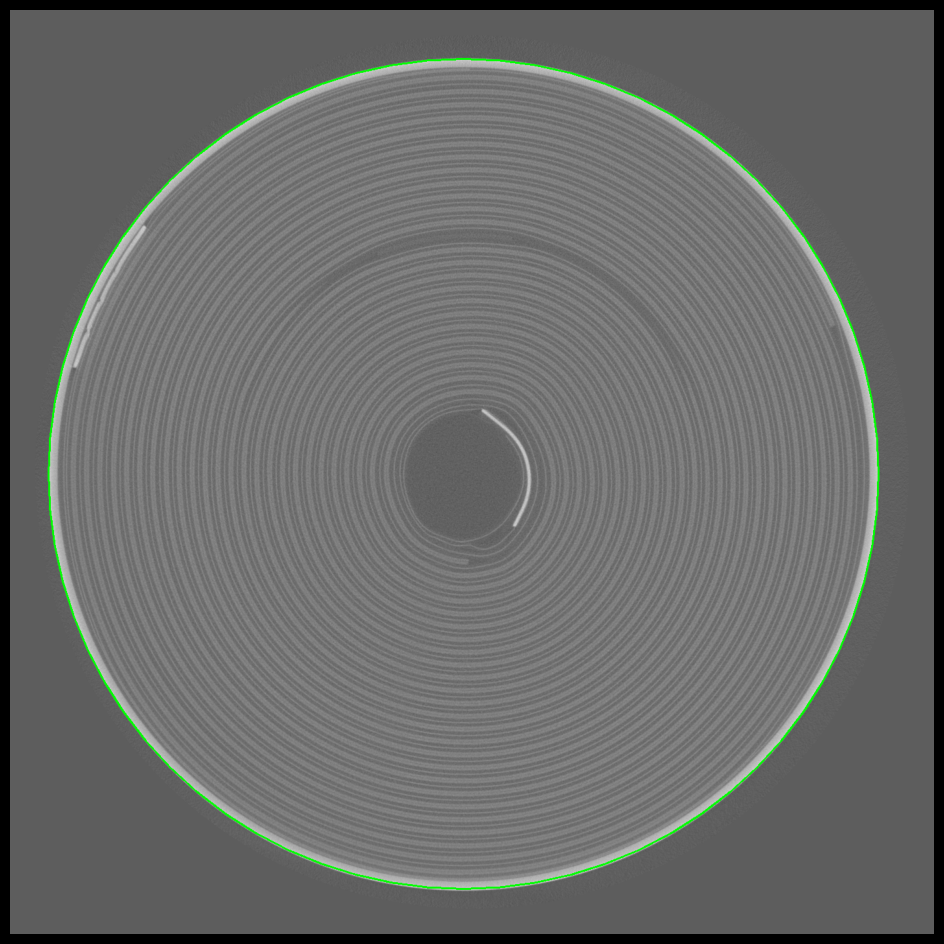

In [22]:
img = slab[0]
print(img.shape)
img_color = cv2.cvtColor(img, cv2.COLOR_GRAY2BGR)
cv2.circle(img_color, (int(cc), int(rc)), int(r), (0, 255, 0), 2)

plt.figure(figsize=(12, 12))
plt.imshow(img_color)
plt.axis("off")
plt.show()
plt.show()

# Polar transformation

In [76]:
H, W = vol.shape[1:]
print(H,W)
n_r, n_theta = H, 2048
r_min = 8.0  # skip singular central annulus
cx, cy = cc, rc
fmap_x, fmap_y, r_min, r_max = build_polar_maps((H, W), cx, cy, n_r, n_theta, r_min)
imap_t, imap_r, valid = build_inverse_maps((H, W), cx, cy, n_r, n_theta, r_min, r_max)

dr = (r_max - r_min) / n_r
print(r_min, r_max, dr)


1425 1425
8.0 1019.1496565227474 0.7095787063317526


In [77]:
polar = cartesian_to_polar(slab[0], fmap_x, fmap_y)
print(r)

#    bg_polar = estimate_background(polar)  # your low-order fit
#    bg_cart = polar_to_cartesian(bg_polar, imap_t, imap_r, valid)
#    residual = sl - bg_cart

640.3305774111145


(1425, 2048)


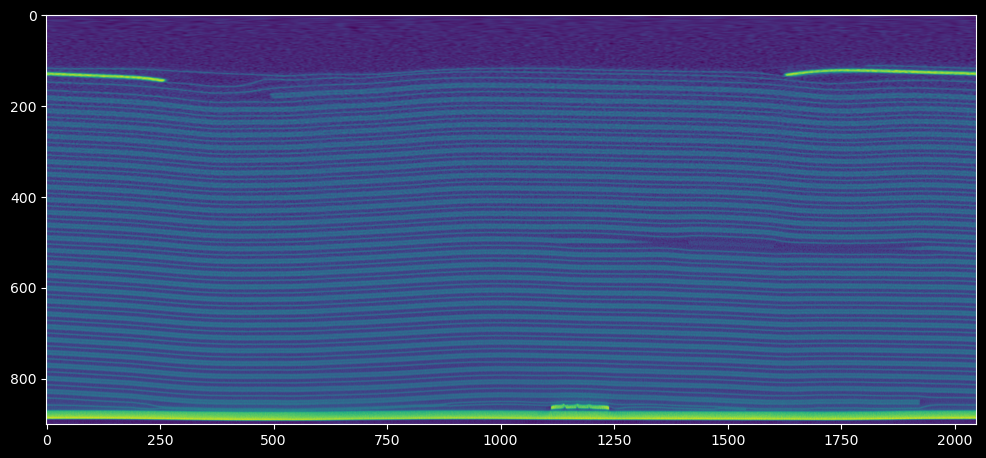

In [79]:
print(polar.shape)
p_max = round((r - r_min)/dr) + 10

plt.figure(figsize=(12, 12))
plt.imshow(polar[:p_max,:])


### Inversion

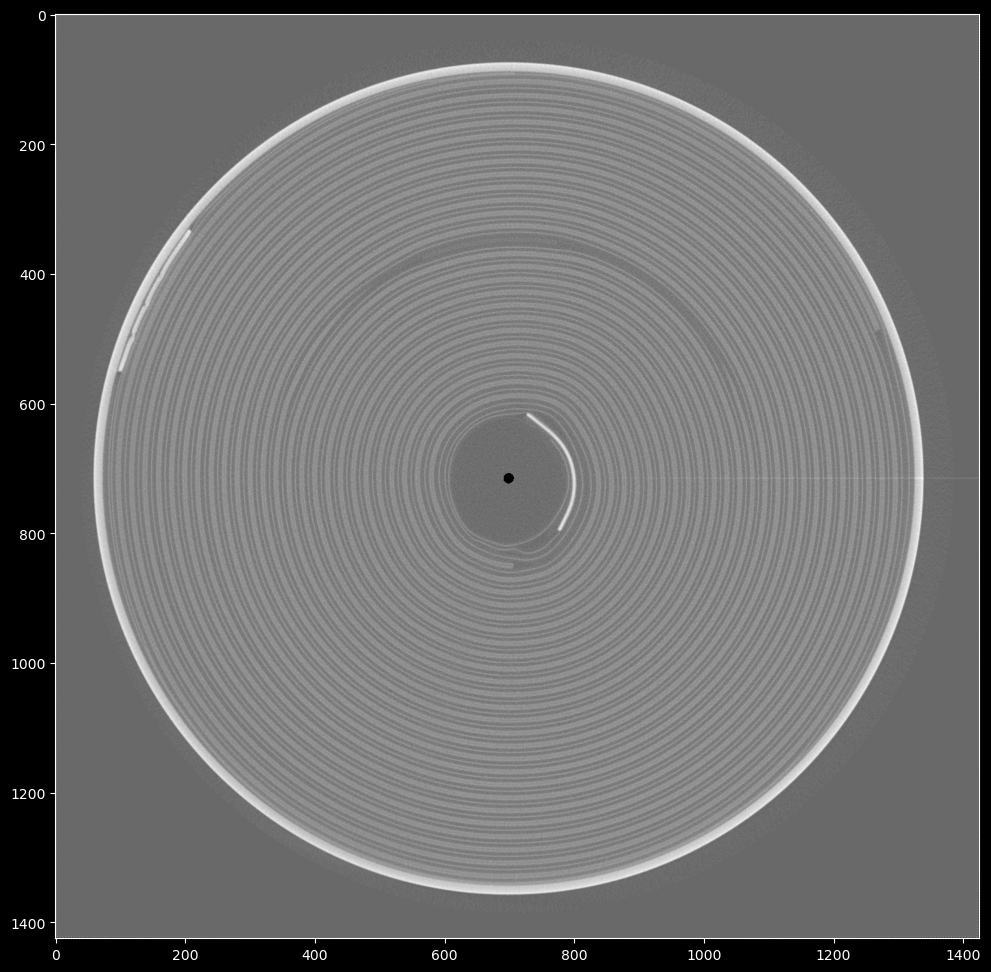

In [80]:
recon_img = polar_to_cartesian(polar, imap_t, imap_r, valid)
plt.figure(figsize=(12, 12))
plt.imshow(recon_img, cmap="gray")

# End